#Disease clasification on plant_disease data


Importing modules
---

In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn pillow torch torchvision timm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os, re, random, numpy as np
from pathlib import Path
from collections import defaultdict
from collections import Counter
from torch.utils.data import WeightedRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
folders = os.listdir('train')
print(len(folders))
print(folders)

83
['tomato late blight', 'cucumber bacterial wilt', 'rice sheath blight', 'coffee black rot', 'celery anthracnose', 'banana black leaf streak', 'soybean downy mildew', 'peach scab', 'broccoli downy mildew', '.DS_Store', 'coffee berry blotch', 'wheat head scab', 'tobacco brown spot', 'peach brown rot', 'coffee leaf rust', 'basil downy mildew', 'apple rust', 'corn northern leaf blight', 'grape leaf spot', 'apple black rot', 'tomato mosaic virus', 'plum rust', 'soybean rust', 'corn smut', 'zucchini powdery mildew', 'tobacco mosaic virus', 'soybean brown spot', 'cabbage alternaria leaf spot', 'wheat powdery mildew', 'peach anthracnose', 'squash powdery mildew', 'tomato early blight', 'plum brown rot', 'wheat loose smut', 'broccoli alternaria leaf spot', 'ginger sheath blight', 'bean rust', 'bell pepper blossom end rot', 'wheat stem rust', 'citrus canker', 'maple tar spot', 'peach leaf curl', 'citrus greening disease', 'wheat septoria blotch', 'zucchini downy mildew', 'lettuce mosaic virus

Data transformation
---

In [6]:
MULTI_WORD_PLANTS = {"bell pepper"}

def parse_folders(root_dir):
    root = Path(root_dir)
    folders = sorted([f for f in root.iterdir() if f.is_dir()])

    disease_set, plant_set = set(), set()
    folder_meta = []

    for folder in folders:
        name = folder.name.lower().strip()
        if name == ".ds_store":
            continue

        matched_plant = next((p for p in MULTI_WORD_PLANTS if name.startswith(p + " ")), None)
        if matched_plant:
            disease_name = name[len(matched_plant)+1:]
        else:
            parts = name.split()
            matched_plant = parts[0]
            disease_name = " ".join(parts[1:])

        disease_set.add(disease_name)
        plant_set.add(matched_plant)
        folder_meta.append((folder, matched_plant, disease_name))

    disease2idx = {d: i for i, d in enumerate(sorted(disease_set))}
    plant2idx = {p: i for i, p in enumerate(sorted(plant_set))}

    print(f"Unique diseases : {len(disease2idx)}")
    print(f"Unique plants   : {len(plant2idx)}")

    samples = []
    for folder, plant_name, disease_name in folder_meta:
        d_idx = disease2idx[disease_name]
        p_idx = plant2idx[plant_name]
        exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
        for img_path in folder.iterdir():
            if img_path.suffix in exts:
                samples.append((str(img_path), d_idx, p_idx))

    print(f"Total images: {len(samples)}")
    return samples, disease2idx, plant2idx

In [7]:
TRAIN_TF = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.25,
        hue=0.05
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.2),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

VAL_TF = transforms.Compose([
    transforms.Resize(256),          # keep aspect ratio
    transforms.CenterCrop(224),      # deterministic crop
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [8]:
class PlantDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, d_idx, p_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, d_idx, p_idx

creating loaders

In [9]:

train_samples, disease2idx, plant2idx = parse_folders("train")
disease_counts = Counter([s[1] for s in train_samples])
print(sorted(disease_counts.items()))

val_samples, _, _ = parse_folders("val")
train_ds = PlantDataset(train_samples, TRAIN_TF)
val_ds   = PlantDataset(val_samples,   VAL_TF)

weights = [1.0 / (disease_counts[s[1]] ** 0.5) for s in train_samples]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32,
                              sampler = sampler,  num_workers=0,
                              pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,
                              shuffle=False, num_workers=0,
                              pin_memory=True)


Unique diseases : 39
Unique plants   : 32
Total images: 7783
[(0, 122), (1, 122), (2, 153), (3, 90), (4, 90), (5, 129), (6, 90), (7, 107), (8, 283), (9, 90), (10, 194), (11, 90), (12, 97), (13, 330), (14, 679), (15, 289), (16, 178), (17, 90), (18, 90), (19, 259), (20, 220), (21, 122), (22, 96), (23, 231), (24, 182), (25, 155), (26, 90), (27, 230), (28, 90), (29, 866), (30, 681), (31, 276), (32, 172), (33, 90), (34, 90), (35, 142), (36, 90), (37, 298), (38, 90)]
Unique diseases : 39
Unique plants   : 31
Total images: 390


Visualization
---

In [8]:
def build_cooccurrence_matrix(samples, disease2idx, plant2idx):
    idx2disease = {v: k for k, v in disease2idx.items()}
    idx2plant   = {v: k for k, v in plant2idx.items()}

    matrix = defaultdict(lambda: defaultdict(int))
    for _, d_idx, p_idx in samples:
        disease_name = idx2disease[d_idx]
        plant_name   = idx2plant[p_idx]
        matrix[plant_name][disease_name] += 1

    df = pd.DataFrame(matrix).fillna(0).astype(int)
    return df

df = build_cooccurrence_matrix(train_samples, disease2idx, plant2idx)

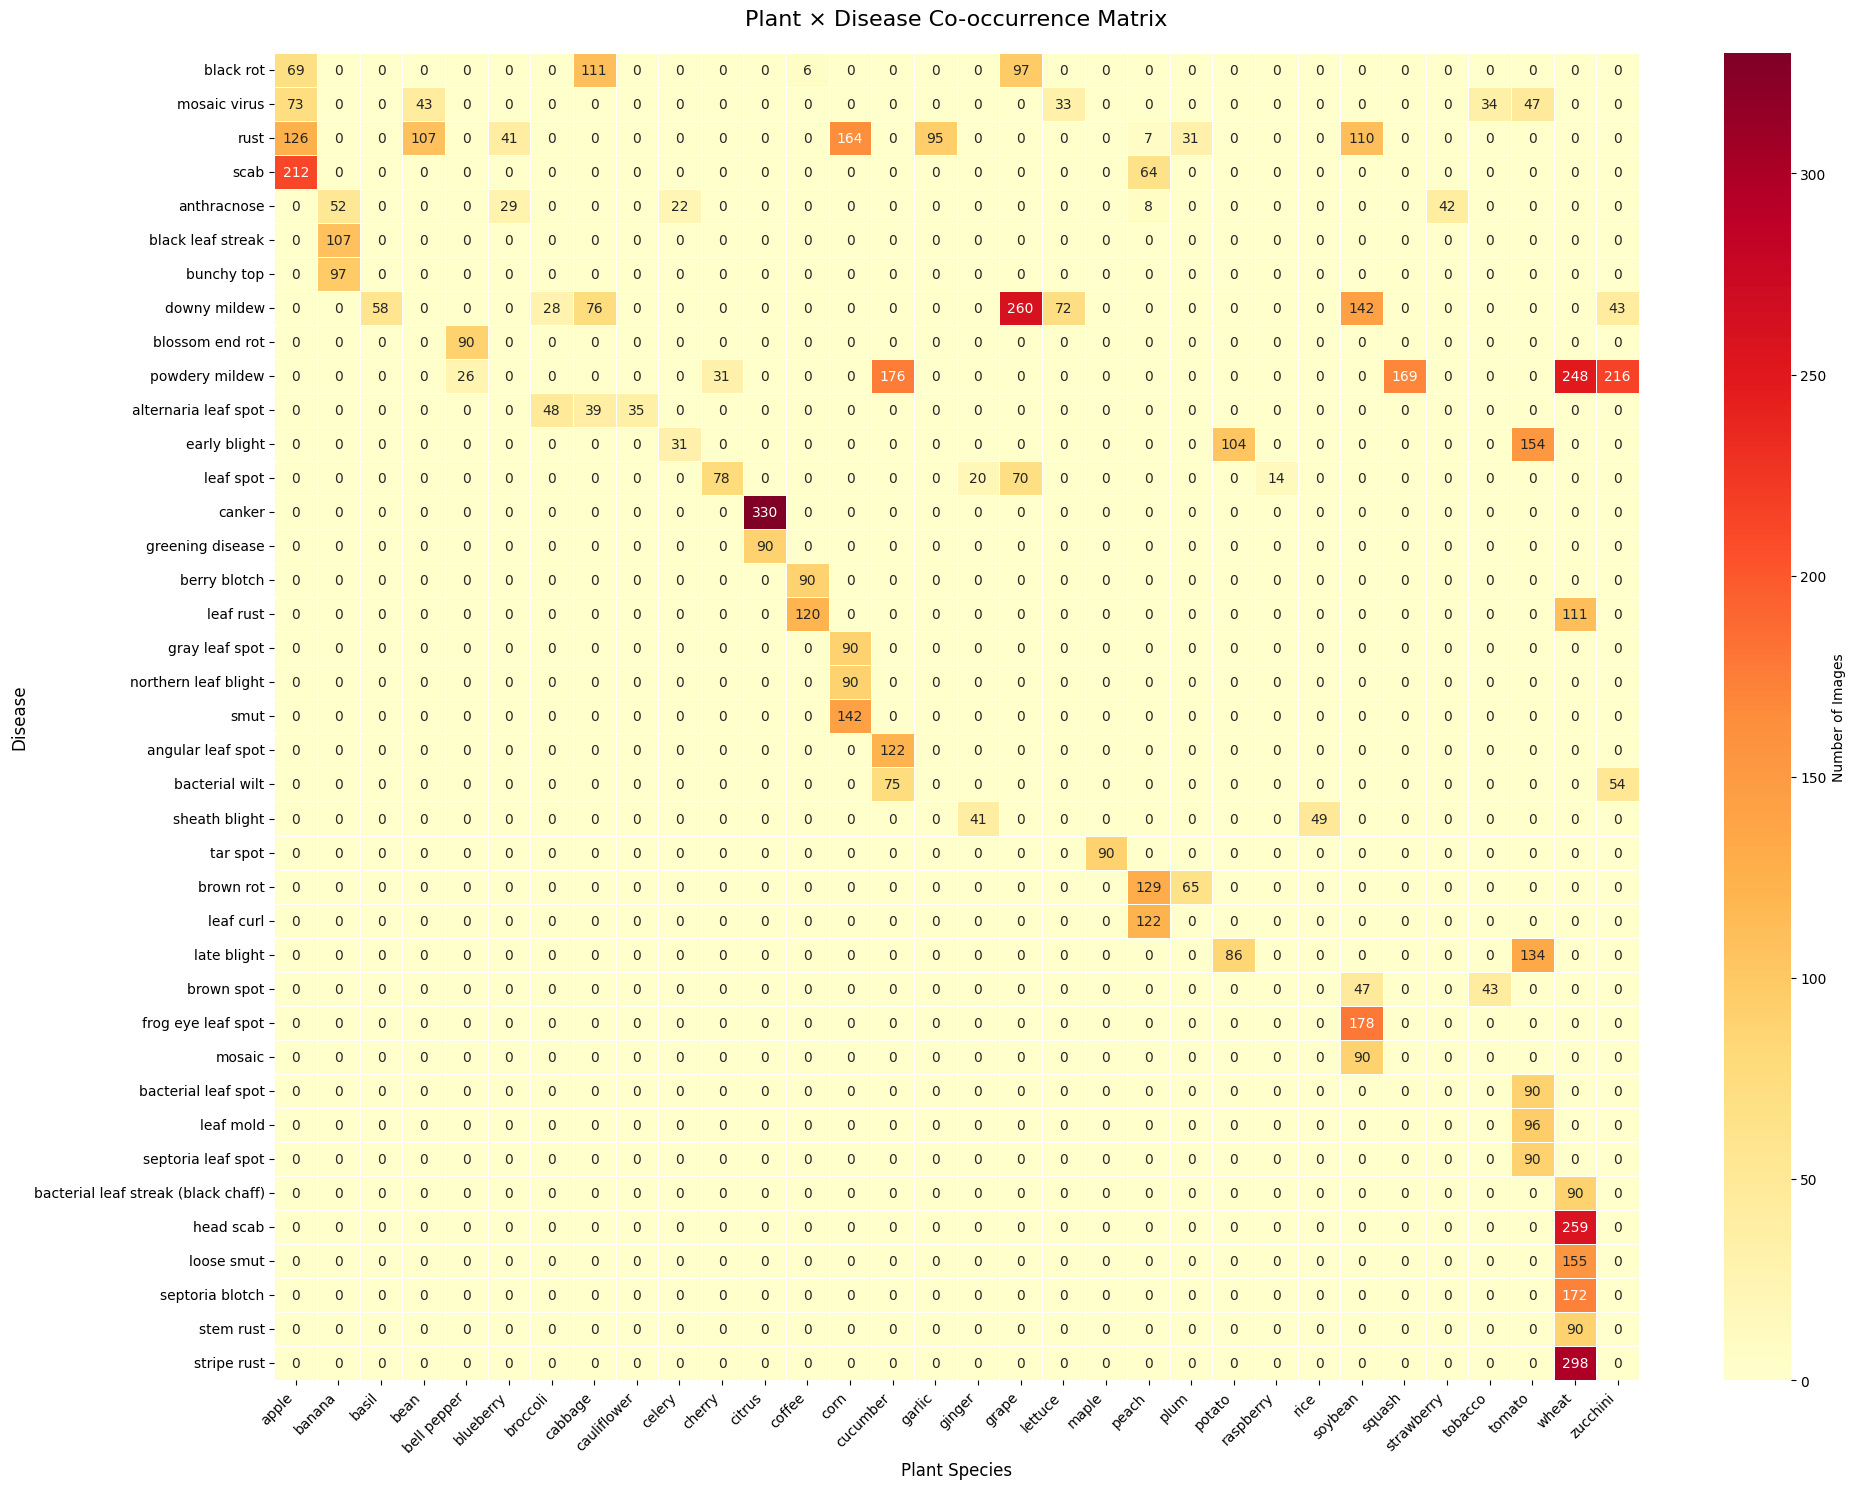

In [9]:
plt.figure(figsize=(20, 15))
sns.heatmap(
    df,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Images'},
)
plt.title("Plant × Disease Co-occurrence Matrix", fontsize=16, pad=20)
plt.xlabel("Plant Species", fontsize=12)
plt.ylabel("Disease", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Model Implementation
---

Gradient reversal layer

In [18]:
class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.save_for_backward(torch.tensor(lambda_))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        lambda_, = ctx.saved_tensors
        return -lambda_ * grad_output, None   # reverse + scale

class GRL(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x, lambda_): return GradientReversalFn.apply(x, lambda_)

def get_lambda(epoch, total_epochs):
    p = epoch / total_epochs
    return (2 / (1 + np.exp(-5 * p)) - 1)


Using EfficentNet0 as a base unfreezing last 2 layers projectiong to another space and applying 2 classification heads(disease and plant)

In [19]:
class DiseaseClassifier(nn.Module):
    def __init__(self, num_diseases, num_plants):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0", pretrained=True, num_classes=0
        )
        feat_dim = self.backbone.num_features

        for p in self.backbone.parameters():
            p.requires_grad = False

        for block in self.backbone.blocks[-2:]:
            for p in block.parameters():
                p.requires_grad = True

        self.projector = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        #Disease classification head
        self.disease_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_diseases),
        )

        #Plant classification head
        self.grl = GRL()
        self.domain_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_plants),
        )

    def forward(self, x, lambda_=1.0):
        feat = self.backbone(x)
        feat = self.projector(feat)

        #Disease prediction
        disease_logits = self.disease_head(feat)

        #Domain adversarial prediction (gradient reversed)
        feat_rev      = self.grl(feat, lambda_)
        domain_logits = self.domain_head(feat_rev)

        return disease_logits, domain_logits


In [12]:
pip install wandb -q

Note: you may need to restart the kernel to use updated packages.


In [13]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/annatitizyan/.netrc.
wandb: Currently logged in as: titizyan-anna (titizyan-anna-yerevan-state-university-ysu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [14]:
wandb.init(
    project="Plant_Disease_Classification",
    name="experiment-14",
    config={
        "learning_rate": 1e-4,
        "epochs": 50,
        "batch_size": 32,
        "weight_decay": 1e-4
    }
)

In [15]:
print(torch.backends.mps.is_available())

True


In [12]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [13]:
def compute_map(y_true, y_prob, num_classes):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_true_onehot = np.eye(num_classes)[y_true]

    ap_per_class = []

    for c in range(num_classes):
        # skip empty classes
        if np.sum(y_true_onehot[:, c]) == 0:
            continue

        ap = average_precision_score(
            y_true_onehot[:, c],
            y_prob[:, c]
        )
        ap_per_class.append(ap)

    return np.mean(ap_per_class)

Training
---

In [14]:
def train_epoch(model, loader, optimizer, criterion, epoch, total_epochs, device):
    model.train()
    
    lambda_ =  get_lambda(epoch, total_epochs)
    if epoch < 4:
        lambda_ = 0.0

    total_loss = 0

    all_probs = []
    all_labels = []

    disease_correct = 0
    disease_total = 0
    plant_correct = 0
    plant_total = 0

    for imgs, d_labels, p_labels in loader:
        imgs = imgs.to(device)
        d_labels = d_labels.to(device)
        p_labels = p_labels.to(device)

        optimizer.zero_grad()

        disease_logits, plant_logits = model(imgs, lambda_)
        d_loss = criterion(disease_logits, d_labels)
        p_loss = criterion(plant_logits, p_labels)
        loss = d_loss + 0.3 * p_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        d_preds = disease_logits.argmax(dim=1)
        disease_correct += (d_preds == d_labels).sum().item()

        disease_total += d_labels.size(0)
        p_preds = plant_logits.argmax(dim=1)
        plant_correct += (p_preds == p_labels).sum().item()
        plant_total += p_labels.size(0)

        probs = torch.softmax(disease_logits, dim=1)
        all_probs.append(probs.detach().cpu())
        all_labels.append(d_labels.detach().cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    mAP = compute_map(all_labels, all_probs, len(disease2idx))

    avg_loss = total_loss / len(loader)
    acc = 100 * disease_correct / disease_total
    plant_acc = 100 * plant_correct / plant_total

    print(
        f"[Train] λ={lambda_:.3f} | "
        f"loss={avg_loss:.4f} | "
        f"acc_disease={acc:.2f}% | "
        f"acc_plant={plant_acc:.2f}% | "
        f"mAP={mAP:.4f}"
    )

    return avg_loss, mAP

In [15]:
@torch.no_grad()
def val_epoch(model, loader, criterion, device, num_classes):
    model.eval()

    total_loss = 0
    correct = total = 0

    all_probs = []
    all_labels = []

    for imgs, d_labels, _ in loader:
        imgs = imgs.to(device)
        d_labels = d_labels.to(device)

        disease_logits, _ = model(imgs, lambda_=0.0)
        loss = criterion(disease_logits, d_labels)

        total_loss += loss.item()

        probs = torch.softmax(disease_logits, dim=1)

        preds = probs.argmax(dim=1)

        correct += (preds == d_labels).sum().item()
        total += len(d_labels)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(d_labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    acc = 100 * correct / total
    map_score = compute_map(all_labels, all_probs, num_classes)

    print(f"  [Val] loss={total_loss/len(loader):.4f} | "
          f"acc={acc:.2f}% | mAP={map_score:.4f}")

    return acc, map_score

In [20]:

# ── Model ─────────────────────────────────────────────────
num_diseases = len(disease2idx)
num_plants   = len(plant2idx)
epochs = 30

model = DiseaseClassifier(num_diseases, num_plants).to(device)

    # Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total_p:,} "
        f"({100*trainable/total_p:.1f}%)\n")

optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
)

criterion = nn.CrossEntropyLoss()

    # ── Training ─────────────────────────────────────────────
best_map = 0

save_path = "best_model.pth"

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    avg_train_loss,train_mAP = train_epoch(model, train_loader, optimizer, criterion,
        epoch, epochs, device)
    val_acc, val_map = val_epoch(model, val_loader, criterion, device, num_diseases)
    wandb.log({
    "train/mAP": train_mAP,
    "val/mAP": val_map,
    "epoch": epoch
})
    scheduler.step()

    if val_map > best_map:
        best_map = val_map
        print(f"✅ best model (mAP={val_map:.4f})")
        torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "best_map": best_map,

        "num_diseases": num_diseases,
        "num_plants": num_plants,

        "disease2idx": disease2idx,
        "plant2idx": plant2idx
        }, save_path)

print(f"\n🏆 Best Val mAP: {best_map:.4f}")
wandb.finish()

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Trainable params: 3,681,379 / 4,945,347 (74.4%)


Epoch 1/30
[Train] λ=0.000 | loss=3.9742 | acc_disease=20.19% | acc_plant=24.51% | mAP=0.1891


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  [Val] loss=2.4121 | acc=36.15% | mAP=0.5379
✅ best model (mAP=0.5379)

Epoch 2/30


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

  [Val] loss=1.2784 | acc=71.54% | mAP=0.7570

Epoch 23/30


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12fa43a50>> (for post_run_cell), with arguments args (<ExecutionResult object at 12fd522d0, execution_count=20 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 12fd52c50, raw_cell="
# ── Model ──────────────────────────────────────.." transformed_cell="# ── Model ───────────────────────────────────────.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/annatitizyan/Desktop/Plant_disease/Plant_Disease_final.ipynb#X40sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [16]:
def predict(image_path,disease2idx,plant2idx, checkpoint_path="best_model.pth"):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    idx2disease = {v: k for k, v in disease2idx.items()}

    model = DiseaseClassifier(len(disease2idx), len(plant2idx)).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img = VAL_TF(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        logits = outputs[0] if isinstance(outputs, tuple) else outputs
        probs = F.softmax(logits, dim=1)[0]
        top5 = probs.topk(5)

    print(f"\nPredictions for: {image_path}")
    for prob, idx in zip(top5.values, top5.indices):
        print(f"{idx2disease[idx.item()]:35s}  {100*prob.item():.2f}%")

In [20]:
predict('/Users/annatitizyan/Desktop/Plant_disease/val/apple scab/apple_scab_google_0060.jpg',disease2idx,plant2idx)


Predictions for: /Users/annatitizyan/Desktop/Plant_disease/val/apple scab/apple_scab_google_0060.jpg
scab                                 47.68%
rust                                 29.88%
powdery mildew                       3.36%
late blight                          2.45%
brown spot                           2.14%
